# 高校数学とPython Day 5【Python版】

- 城北中学校・高等学校　中学3年・高校1年
- 夏期講習会III 2026/8/24~2026/8/28
- 担当:清水団

## 本日のテーマ:確率とシミュレーション

Julia版と同じ内容を **Python** で体験するバージョンです。言語ごとの書き方の違いにも注目してみてください。

### 5日間の学習予定

- **Day 1**:基本計算・for文・if文 ✅
- **Day 2**:整数問題をプログラムで考えよう ✅
- **Day 3**:場合の数・組合せを実験しよう ✅
- **Day 4**:関数・グラフ・最大最小 ✅
- **Day 5**:確率・シミュレーション ← 今日


## 準備

In [1]:
!pip install japanize-matplotlib -q
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

print("準備完了!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 18.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
準備完了!


## コイン投げのシミュレーション

In [2]:
random.random()  # 0以上1未満の乱数(実行のたびに変わる!)

0.9249458271670378

In [3]:
# 10回のコイン投げ
for i in range(1, 11):
    print(f"{i}回目: {'表' if random.random() < 0.5 else '裏'}")

1回目: 裏
2回目: 表
3回目: 表
4回目: 裏
5回目: 裏
6回目: 表
7回目: 表
8回目: 表
9回目: 表
10回目: 表


In [4]:
# 回数を増やすと0.5に近づく?
for n in [10, 100, 1000, 10000, 100000, 1000000]:
    omote = sum(1 for _ in range(n) if random.random() < 0.5)
    print(f"{n} 回 → 表の割合 {omote/n}")

10 回 → 表の割合 0.3
100 回 → 表の割合 0.45
1000 回 → 表の割合 0.496
10000 回 → 表の割合 0.4974
100000 回 → 表の割合 0.50284
1000000 回 → 表の割合 0.500372


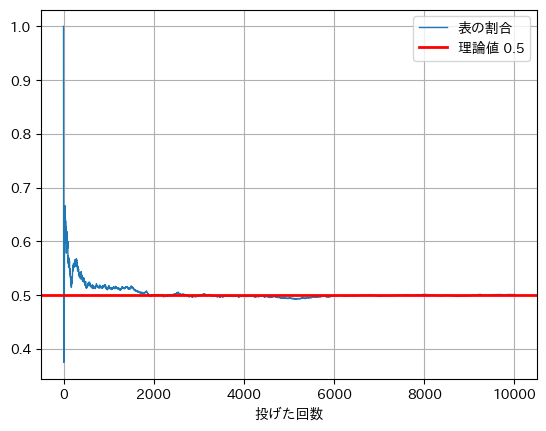

In [5]:
# 大数の法則をグラフで
n = 10000
results = np.random.rand(n) < 0.5
ratios = np.cumsum(results) / np.arange(1, n + 1)
plt.plot(ratios, lw=1, label="表の割合")
plt.axhline(0.5, color="red", lw=2, label="理論値 0.5")
plt.xlabel("投げた回数"); plt.legend(); plt.grid(); plt.show()

## サイコロのシミュレーション

In [6]:
n = 60000
rolls = np.random.randint(1, 7, n)
for me in range(1, 7):
    k = np.sum(rolls == me)
    print(f"{me} の目: {k} 回(割合 {k/n:.4f})")
# 理論値 1/6 ≈ 0.1667

1 の目: 10009 回(割合 0.1668)
2 の目: 10009 回(割合 0.1668)
3 の目: 10054 回(割合 0.1676)
4 の目: 9885 回(割合 0.1648)
5 の目: 10043 回(割合 0.1674)
6 の目: 10000 回(割合 0.1667)


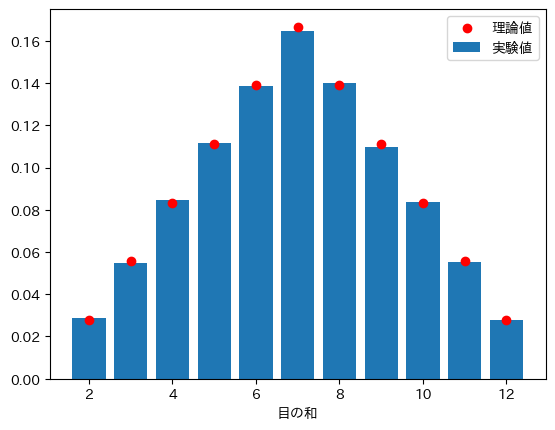

In [7]:
# 2つのサイコロの和
n = 100000
sums = np.random.randint(1, 7, n) + np.random.randint(1, 7, n)
vals, counts = np.unique(sums, return_counts=True)
plt.bar(vals, counts / n, label="実験値")
riron = [min(s - 1, 13 - s)/36 for s in vals]
plt.scatter(vals, riron, color="red", zorder=3, label="理論値")
plt.xlabel("目の和"); plt.legend(); plt.show()

## 誕生日問題:直感 vs 確率

In [8]:
def birthday_experiment(k, trials=10000):
    hits = 0
    for _ in range(trials):
        bd = np.random.randint(1, 366, k)
        if len(np.unique(bd)) < k:
            hits += 1
    return hits / trials

def birthday_theory(k):
    p = 1.0
    for i in range(k):
        p *= (365 - i) / 365
    return 1 - p

print("実験値:", birthday_experiment(40))
print("理論値:", birthday_theory(40))

実験値: 0.8905
理論値: 0.891231809817949


## モンティ・ホール問題

In [9]:
def monty_hall(change):
    doors = [1, 2, 3]
    atari = random.choice(doors)
    choice = random.choice(doors)
    host = random.choice([d for d in doors if d != atari and d != choice])
    if change:
        choice = [d for d in doors if d != choice and d != host][0]
    return choice == atari

n = 100000
print("変えない戦略の勝率:", sum(monty_hall(False) for _ in range(n)) / n)
print("変える戦略の勝率:  ", sum(monty_hall(True) for _ in range(n)) / n)

変えない戦略の勝率: 0.33181
変える戦略の勝率:   0.66718


## モンテカルロ法:乱数で円周率

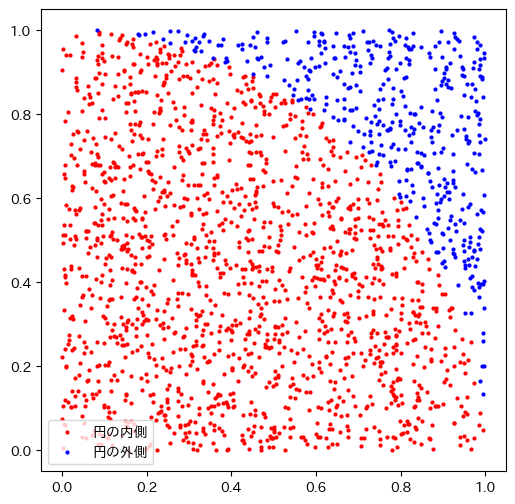

In [10]:
# 点を2000個打って可視化
n = 2000
xs, ys = np.random.rand(n), np.random.rand(n)
inside = xs**2 + ys**2 <= 1
plt.figure(figsize=(6, 6))
plt.scatter(xs[inside], ys[inside], s=4, color="red", label="円の内側")
plt.scatter(xs[~inside], ys[~inside], s=4, color="blue", label="円の外側")
plt.legend(); plt.show()

In [11]:
def monte_carlo_pi(n):
    xs, ys = np.random.rand(n), np.random.rand(n)
    return 4 * np.sum(xs**2 + ys**2 <= 1) / n

for n in [100, 10000, 1000000, 100000000]:
    print(f"{n} 個の点 → π ≈ {monte_carlo_pi(n)}")
print("本当のπ  =", math.pi)

100 個の点 → π ≈ 3.28
10000 個の点 → π ≈ 3.1376
1000000 個の点 → π ≈ 3.142616
100000000 個の点 → π ≈ 3.14148864
本当のπ  = 3.141592653589793


## Day 5 の演習問題

### 問題1: コイン3枚とも表の確率(理論値 1/8 と比較)
### 問題2: サイコロ2個の「大きい方の目」の平均値
### 問題3: 扉4つのモンティ・ホール
### 問題4: 自由課題(じゃんけん・くじ引き・ランダムウォーク…)

## 解答欄

In [12]:
# 問題1



In [13]:
# 問題2



In [14]:
# 問題3



In [15]:
# 問題4



## 5日間のまとめ

Python版でも同じ結論にたどり着きました:

**数学の理論は、実験で確かめられる。実験は、新しい理論の入り口になる。**

言語が変わっても「実験する数学」の考え方は同じ。JuliaとPythonの書き方の違いを見比べるのも面白い勉強です!